# Gridsynth

The main task of `gridsynth` is to take
$$
R_Z(\theta) = 
\begin{pmatrix}
\mathrm{e}^{-i\theta/2} & 0 \\
0 & \mathrm{e}^{i\theta/2}
\end{pmatrix}
$$

and find a circuit that roughly implements this rotation
$$
R_Z(\theta) = C_1T^{k_1}C_2T^{k_2}\dots C_n
$$

where the $C_i$'s are the Clifford operations and the $T$ gates are the non-clifford gates. In the paper they specify bits of accuracy, which essentially means choosing an error target of $\epsilon \sim 2^{-b}$ where b is the number of bits. They state the scaling is typically
$$
\text{Number of Clifford gates} = 3\log_2 \left(\frac1\epsilon\right) + O\left(\log\left(\log\left(\frac1\epsilon\right)\right)\right)
$$

which means roughly $3b$ T gates. In the paper, they vary the accuracy from 1 to 32 bits, which means we're essentially doing:
```py
for b = 1, 2, ..., 32:
    epsilon = 2^(-b)

    for i = 1, ..., 1000:
        generate QPE circuit
        find every RZ(theta)
        replace each RZ(theta) with a Gridsynth approximation
             at accuracy epsilon

        simulate the resulting Clifford+T circuit
        repeat measurement 10,000 times
``` 

The software is available in python in the form of `pygridsynth` which will be our main tool.

In [1]:
import pygridsynth as gs
import numpy as np
import matplotlib.pyplot as plt
import mpmath

import qutip as q
from qutip_qip.circuit import QubitCircuit
from qutip_qip.operations import Gate, hadamard_transform
from pygridsynth.gridsynth import gridsynth_circuit
from pygridsynth.quantum_gate import HGate, TGate, SGate, SXGate, WGate

First, we reuse the code form `Trotterization-QPE.ipynb` with slight changes. We replace the custom gates with their exact Clifford + single-qubit RZ decompositions. Using θ=t/2, the ZZ rotation is implemented as CNOT → RZ(theta) → CNOT, while the ZX rotation is implemented as H → CNOT → RZ(theta) → CNOT → H on the appropriate qubits. The QPE circuit now explicitly contains these decomposed gates instead of the original custom two-qubit matrix gates; the decomposition is still exact, so no approximation has been introduced yet. The next step is to simplify the repeated ZZ → ZX → ZX → ZZ sequence before replacing the RZ gates with Gridsynth approximations.

This code, along with helper functions, is found in `generate_qpe.py`.

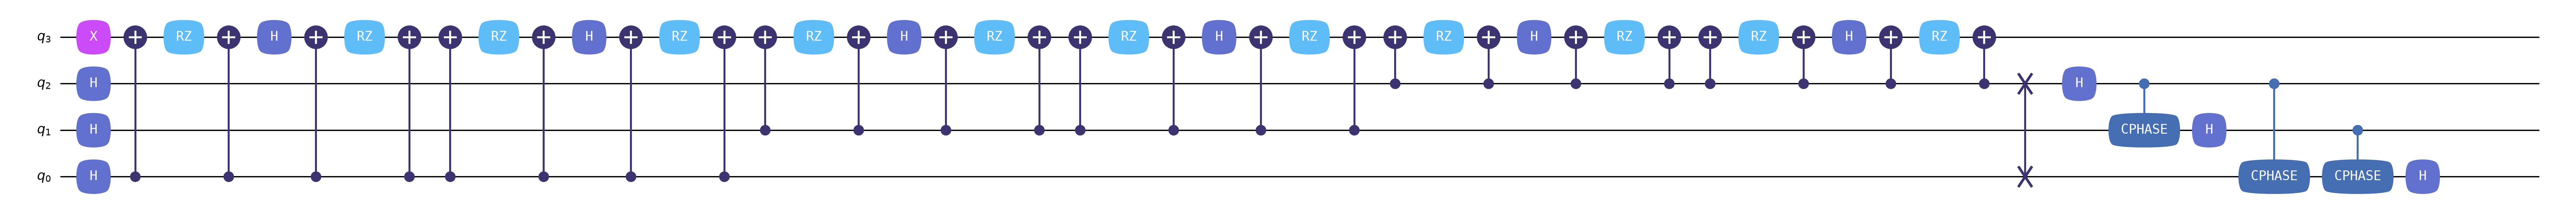

In [2]:
import generate_qpe as qpe

qc = qpe.generate_qpe_circuit()

qc.draw("matplotlib", dpi=300)

## Main simulation function

In [3]:
def simulate(qc, shots=10000, seed=None, return_probabilities=False):
    rng = np.random.default_rng(seed)  # set rng
    N = qc.N  # number of qubits
    psi = q.tensor(
        [q.basis(2, 0) for _ in range(N)]
    )  # tensor N 2D ground states as our initial state psi

    # loop through each gate in the QPE circuit
    for gate in qc.gates:
        # define name, target, and control
        name = gate.name.upper()
        targets = gate.targets
        controls = gate.controls

        # set the full unitary based on the gate name
        if name == "H":
            U = hadamard_transform(1)
            full_U = q.tensor([U if i == targets[0] else q.qeye(2) for i in range(N)])
        elif name == "X":
            U = q.sigmax()
            full_U = q.tensor([U if i == targets[0] else q.qeye(2) for i in range(N)])
        elif name == "T":
            U = q.Qobj(np.diag([1, np.exp(1j * np.pi / 4)]))
            full_U = q.tensor([U if i == targets[0] else q.qeye(2) for i in range(N)])
        elif name == "S":
            U = q.Qobj(np.diag([1, 1j]))
            full_U = q.tensor([U if i == targets[0] else q.qeye(2) for i in range(N)])
        elif name == "CNOT":
            control = controls[0]
            target = targets[0]
            P0 = (q.qeye(2) + q.sigmaz()) / 2
            P1 = (q.qeye(2) - q.sigmaz()) / 2
            ops0 = [q.qeye(2) for _ in range(N)]
            ops1 = [q.qeye(2) for _ in range(N)]
            ops0[control] = P0
            ops1[control] = P1
            ops1[target] = q.sigmax()
            full_U = q.tensor(ops0) + q.tensor(ops1)
        elif name == "RZ":
            theta = gate.arg_value
            U = (-1j * theta * q.sigmaz() / 2).expm()
            full_U = q.tensor([U if i == targets[0] else q.qeye(2) for i in range(N)])
        elif name == "SWAP":
            a, b = targets
            full_U = qpe.swap_operator(a, b, N)
        elif name == "CPHASE":
            control = controls[0]
            target = targets[0]
            theta = gate.arg_value
            cphase = q.Qobj(
                np.diag([1, 1, 1, np.exp(1j * theta)]), dims=[[2, 2], [2, 2]]
            )
            full_U = qpe.embed_two_qubit_gate(cphase, control, target, N)
        else:
            raise NotImplementedError(
                f"Gate {gate.name!r} is not supported"
            )  # raise error if gate is not implemented

        # apply full unitary to state psi
        psi = full_U * psi

    # get probabilities from new psi
    probabilities = np.abs(psi.full().flatten()) ** 2
    probabilities /= probabilities.sum()
    if return_probabilities:
        return probabilities

    # sample randomly
    samples = rng.choice(2**N, size=shots, p=probabilities)
    counts = {}

    # turn sample index into bitstring and save counts with bitstring index
    for index in samples:
        bitstring = format(index, f"0{N}b")
        counts[bitstring] = counts.get(bitstring, 0) + 1
    return counts

## Executing

In [4]:
# lists to save data for visualization
tv_results = []
gate_results = []

# initialize circuit and simulate once
qc = qpe.generate_qpe_circuit()
ideal_counts = simulate(qc, shots=10000, seed=0)  # get ideal baseline counts

# loop for each bit of accuracy
for b in range(1, 33):
    # decompose the qpe circuit with gridsynth and get number of gates
    qc_gridsynth = qpe.decompose_qpe_with_gridsynth(qc, bits=b)
    gate_results.append(len(qc_gridsynth.gates))

    tv_distances = []  # list for total variation distances

    # loop for a number of iterations -> paper does 10.000
    for i in range(100):
        counts = simulate(qc_gridsynth, shots=10000)  # get gridynth counts

        # calculate TV distance between counts and ideal counts
        tv_distance = 0.5 * sum(
            abs(counts.get(x, 0) / 10000 - ideal_counts.get(x, 0) / 10000)
            for x in set(counts) | set(ideal_counts)
        )
        tv_distances.append(tv_distance)
    tv_results.append(np.mean(tv_distances))  # append mean

/Users/julianlindemann/Documents/Uni/Master/Summer/SCQIS/chem-compilation/.venv/lib/python3.14/site-packages/pygridsynth/gridsynth.py:362: UserWarning: pygridsynth is synthesizing the angle 1.620620405021406. Please verify that this is the intended value. Using float may introduce precision errors; consider using mpmath.mpf for exact precision.
  theta, epsilon = convert_theta_and_epsilon(theta, epsilon, dps=cfg.dps)
/Users/julianlindemann/Documents/Uni/Master/Summer/SCQIS/chem-compilation/.venv/lib/python3.14/site-packages/pygridsynth/gridsynth.py:362: UserWarning: pygridsynth is synthesizing the angle 3.241240810042812. Please verify that this is the intended value. Using float may introduce precision errors; consider using mpmath.mpf for exact precision.
  theta, epsilon = convert_theta_and_epsilon(theta, epsilon, dps=cfg.dps)
/Users/julianlindemann/Documents/Uni/Master/Summer/SCQIS/chem-compilation/.venv/lib/python3.14/site-packages/pygridsynth/gridsynth.py:362: UserWarning: pygrid

## Final plot

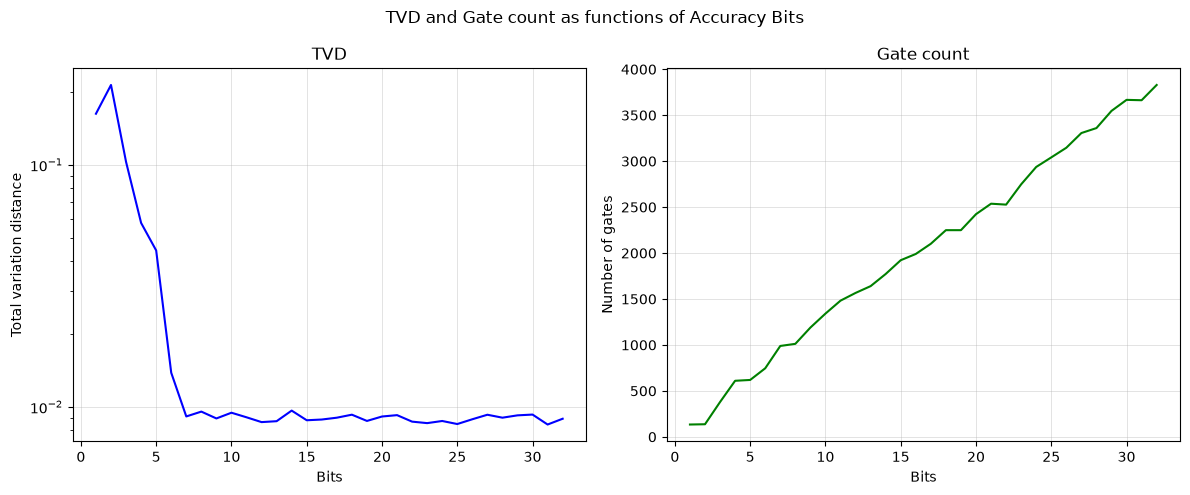

In [5]:
bits = np.arange(1, 33)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(bits, tv_results, color="blue")
axes[0].set_yscale("log")
axes[0].set_xlabel("Bits")
axes[0].set_ylabel("Total variation distance")
axes[0].set_title("TVD")
axes[0].grid()

axes[1].plot(bits, gate_results, color="green")
axes[1].set_xlabel("Bits")
axes[1].set_ylabel("Number of gates")
axes[1].set_title("Gate count")
axes[1].grid()

fig.suptitle("TVD and Gate count as functions of Accuracy Bits")

plt.tight_layout()
plt.show()

The overall trends appear quite similar; the gate count is lower in the reproduced version, likely due to a subtle difference in gate decomposition or counting methods. Other differences in trends is also due to the paper's 10000 simulation iterations.